In [ ]:
from google.colab import files
files.upload()

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             roc_auc_score, f1_score, classification_report,
                             confusion_matrix, roc_curve)
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, Input, BatchNormalization
from tensorflow.keras.regularizers import l1, l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

np.random.seed(42)
tf.random.set_seed(42)

def load_data(train_path, test_path):
    train_df = pd.read_csv(train_path, sep=' ')
    test_df  = pd.read_csv(test_path,  sep=' ')

    X_train_raw = train_df.drop(columns=['RID', 'Phenotype']).values
    y_train     = train_df['Phenotype'].values
    X_test_raw  = test_df.drop(columns=['RID', 'Phenotype']).values
    y_test      = test_df['Phenotype'].values

    return X_train_raw, y_train, X_test_raw, y_test

X_train_raw, y_train_full, X_test_raw, y_test = load_data(
    'training_set_1e-4.txt', 'holdout_set_1e-4.txt'
)
N_var = X_train_raw.shape[1]
print(f"Số lượng features (SNPs): {N_var}")


def create_model(n_var, learning_rate=1e-4):
    inputs = Input(shape=(n_var,))

    x = Dropout(0.3)(inputs)
    x = Dense(128, activation='sigmoid',
              kernel_regularizer=l1(5e-5))(x)
    x = Dropout(0.3)(x)

    x = Dense(64, activation='sigmoid',
              kernel_regularizer=l1(5e-5))(x)

    x = Dense(22, activation='sigmoid')(x)
    x = Dense(5, activation='sigmoid')(x)
    outputs = Dense(1, activation='sigmoid')(x)

    model = Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

classes = np.unique(y_train_full)
weights = compute_class_weight('balanced', classes=classes, y=y_train_full)
class_weight_dict = dict(zip(classes, weights))
print(f"Class weights: {class_weight_dict}")


kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores   = []
best_epochs = []

print("\n--- Bắt đầu Stratified 5-Fold Cross-Validation ---")
for fold, (train_idx, val_idx) in enumerate(kfold.split(X_train_raw, y_train_full)):
    print(f"Đang huấn luyện Fold {fold + 1}...")


    X_fold_train_raw = X_train_raw[train_idx]
    X_fold_val_raw   = X_train_raw[val_idx]
    y_fold_train     = y_train_full[train_idx]
    y_fold_val       = y_train_full[val_idx]


    scaler = StandardScaler()
    X_fold_train = scaler.fit_transform(X_fold_train_raw)
    X_fold_val   = scaler.transform(X_fold_val_raw)

    model_cv = create_model(N_var, learning_rate=1e-4)

    early_stop = EarlyStopping(
        monitor='accuracy',
        patience=150,
        restore_best_weights=True,
        mode='max'
    )
    reduce_lr = ReduceLROnPlateau(
        monitor='accuracy',
        factor=0.95,
        patience=20,
        mode='max',
        min_lr=1e-6,
        verbose=0
    )

    history = model_cv.fit(
        X_fold_train, y_fold_train,
        validation_data=(X_fold_val, y_fold_val),
        epochs=1000,
        batch_size=256,
        class_weight=class_weight_dict,
        callbacks=[early_stop, reduce_lr],
        verbose=0
    )


    if early_stop.stopped_epoch > 0:
        optimal_epoch = early_stop.stopped_epoch - early_stop.patience + 1
    else:
        optimal_epoch = 1000
    best_epochs.append(optimal_epoch)

    val_preds_prob = model_cv.predict(X_fold_val, verbose=0)
    fold_auc = roc_auc_score(y_fold_val, val_preds_prob)
    cv_scores.append(fold_auc)
    print(f"  Fold {fold + 1} — Epoch tốt nhất: {optimal_epoch} | Val AUC: {fold_auc:.4f}")

avg_optimal_epoch = max(int(np.mean(best_epochs)), 300)
print(f"\nAverage AUC: {np.mean(cv_scores):.4f} ± {np.std(cv_scores):.4f}")
print(f"Số epoch retrain: 1000\n")


final_scaler = StandardScaler()
X_train_scaled = final_scaler.fit_transform(X_train_raw)
X_test_scaled  = final_scaler.transform(X_test_raw)

final_model = create_model(N_var, learning_rate=1e-4)
print(final_model.summary())
final_model.fit(
    X_train_scaled, y_train_full,
    epochs=avg_optimal_epoch,
    batch_size=256,
    class_weight=class_weight_dict,
    verbose=1
)

y_pred_probs = final_model.predict(X_test_scaled)
y_preds      = (y_pred_probs > 0.5).astype(int)

acc  = accuracy_score(y_test, y_preds)
prec = precision_score(y_test, y_preds)
rec  = recall_score(y_test, y_preds)
f1   = f1_score(y_test, y_preds)
auc  = roc_auc_score(y_test, y_pred_probs)

print("\n=== RESULT ON TEST SET ===")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-Score : {f1:.4f}")
print(f"AUC_ROC  : {auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_preds,
      target_names=['Control (0)', 'Alzheimer (1)']))
"""
# ==========================================
# BƯỚC 6: TRỰC QUAN HÓA
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0],
            xticklabels=['Control', 'Alzheimer'],
            yticklabels=['Control', 'Alzheimer'])
axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Dự đoán')
axes[0].set_ylabel('Thực tế')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_probs)
axes[1].plot(fpr, tpr, color='red', lw=2, label=f'AUC = {auc:.4f}')
axes[1].plot([0,1],[0,1], 'navy', lw=2, linestyle='--')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend(loc='lower right')

# Risk Score Distribution
sns.kdeplot(y_pred_probs[y_test==0].ravel(), fill=True,
            color='blue', label='Control (0)', ax=axes[2])
sns.kdeplot(y_pred_probs[y_test==1].ravel(), fill=True,
            color='red',  label='Alzheimer (1)', ax=axes[2])
axes[2].set_title('PRS Risk Score Distribution')
axes[2].set_xlabel('Predicted Probability')
axes[2].set_ylabel('Mật độ (Density)')
axes[2].legend()

plt.tight_layout()
plt.savefig('results.png', dpi=150, bbox_inches='tight')
plt.show()
"""

Số lượng features (SNPs): 7476
Class weights: {np.int64(0): np.float64(1.02880658436214), np.int64(1): np.float64(0.9727626459143969)}

--- Bắt đầu Stratified 5-Fold Cross-Validation ---
Đang huấn luyện Fold 1...


KeyboardInterrupt: 

In [ ]:
import tensorflow as tf

# Kiểm tra danh sách các thiết bị vật lý
gpu_devices = tf.config.list_physical_devices('GPU')

if gpu_devices:
    print(f"✅ Đã tìm thấy {len(gpu_devices)} GPU:")
    for gpu in gpu_devices:
        print(f"  - {gpu}")
    # Thiết lập để TensorFlow không chiếm dụng toàn bộ VRAM ngay lập tức (Memory Growth)
    try:
        for gpu in gpu_devices:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("✅ Đã bật Memory Growth cho GPU")
    except RuntimeError as e:
        print(e)
else:
    print("❌ Không tìm thấy GPU. Vui lòng kiểm tra lại thiết lập Runtime (Runtime -> Change runtime type -> Hardware accelerator: GPU).")

✅ Đã tìm thấy 1 GPU:
  - PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
✅ Đã bật Memory Growth cho GPU


In [ ]:
!nvidia-smi

Mon Apr  6 09:33:28 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8             14W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# Confusion Matrix
plt.figure(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Control', 'Alzheimer'],
    cmap='Blues', values_format='d'
)
plt.savefig('plots/adni_1e-8_lasso_2_confusion_matrix.pdf', dpi=300, bbox_inches='tight')
plt.show()

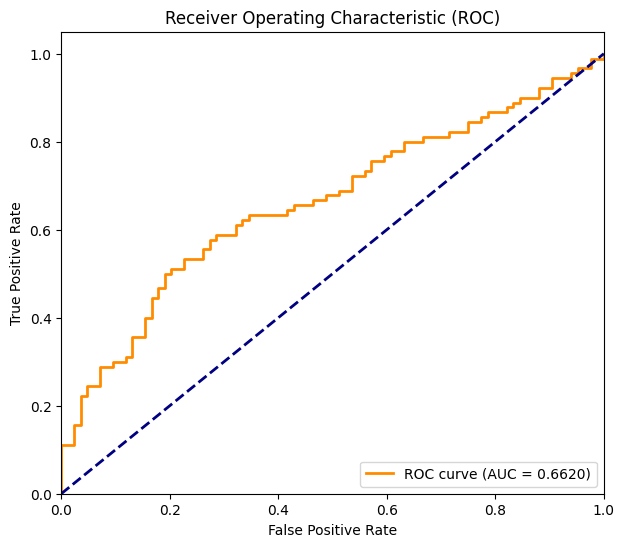

In [ ]:
import os
from sklearn.metrics import roc_curve, RocCurveDisplay

# Create the 'plots' directory if it doesn't exist
os.makedirs('plots', exist_ok=True)

# ROC Curve
plt.figure(figsize=(7, 6))
fpr, tpr, _ = roc_curve(y_test, y_pred_probs)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.savefig('plots/MLP_roc_curve.pdf', dpi=300, bbox_inches='tight')
plt.show()

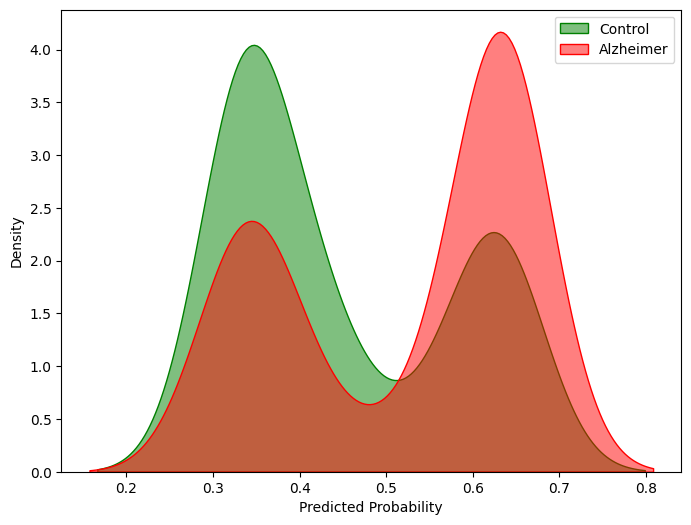

In [ ]:
import os

# Create the 'plots' directory if it doesn't exist
os.makedirs('plots', exist_ok=True)

# Risk Score Distribution
plt.figure(figsize=(8, 6))
sns.kdeplot(y_pred_probs[y_test == 0].ravel(), label='Control', fill=True, color='green', alpha=0.5)
sns.kdeplot(y_pred_probs[y_test == 1].ravel(), label='Alzheimer', fill=True, color='red', alpha=0.5)
plt.xlabel('Predicted Probability')
plt.ylabel('Density')
plt.legend()
plt.savefig('plots/MLP_risk_score_distribution.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import os

# Đảm bảo thư mục 'results' tồn tại
os.makedirs('results', exist_ok=True)

# Tải lại test_df để có cột 'RID'
test_df_original = pd.read_csv('test_dataset_1e-8.txt', sep=' ')

# Tạo DataFrame chứa RID và xác suất dự đoán
prs_df = pd.DataFrame({
    'RID': test_df_original['RID'].values,
    'Predicted_PRS': y_pred_probs.flatten()
})

# Lưu DataFrame vào file CSV
output_filename = 'results/patient_prs_scores.csv'
prs_df.to_csv(output_filename, index=False)

print(f"Đã lưu điểm PRS của bệnh nhân vào file: {output_filename}")
print("5 hàng đầu tiên của file PRS:")
print(prs_df.head())


Đã lưu điểm PRS của bệnh nhân vào file: results/patient_prs_scores.csv
5 hàng đầu tiên của file PRS:
    RID  Predicted_PRS
0  5252       0.365697
1  6362       0.338131
2   803       0.353707
3  4320       0.329210
4  4733       0.634351


In [ ]:
import os

# Save trained models
os.makedirs('models', exist_ok=True)

model_weights_filename = 'models/mlp_model_1e-8.weights.h5'
final_model.save_weights(model_weights_filename)

print(f"Đã lưu trọng số mô hình vào file: {model_weights_filename}")

Đã lưu trọng số mô hình vào file: models/mlp_model_1e-8.weights.h5
